# Feature Engineering

Feature engineering is the process of transforming raw data into meaningful features that improve the predictive performance of machine learning models.

For a retail sales forecasting problem, feature engineering plays a crucial role because weekly sales are influenced by temporal patterns, promotional campaigns, store characteristics, holidays, and economic conditions.

The objective of this notebook is to create informative features while preserving the business meaning of the data.

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

In [ ]:
df = pd.read_csv("walmart_merged.csv")

df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315


# 2. Time Series Feature Engineering

Retail sales exhibit strong temporal dependencies, meaning that current sales are often influenced by previous weeks' performance.

To capture these historical patterns, lag-based and rolling window features are created.

Before generating these features, the dataset must be sorted chronologically within each Store–Department combination to ensure that only past information is used for forecasting.

In [ ]:
# Sort data before creating time-series features
df = df.sort_values(
    by=['Store', 'Dept', 'Date']
).reset_index(drop=True)

df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315


Why do we sort first?

Because lag features must always refer to past observations.

If the data isn't sorted chronologically, the lag feature could accidentally use a future value, causing data leakage and producing unrealistically good model performance.

## 2.1 Lag Features

Lag features represent sales from previous weeks.

They enable the model to learn temporal dependencies by providing historical sales information as predictors for future sales.

For example, the sales from the previous week (Lag-1) often serve as a strong indicator of the current week's sales.

In [ ]:
lag_features = [1, 2, 4, 8, 12, 52]

for lag in lag_features:
    df[f'Lag_{lag}'] = (
        df.groupby(['Store', 'Dept'])['Weekly_Sales']
          .shift(lag)
    )

df.head(15)

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,...,CPI,Unemployment,Type,Size,Lag_1,Lag_2,Lag_4,Lag_8,Lag_12,Lag_52
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,...,211.096358,8.106,A,151315,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,...,211.242170,8.106,A,151315,24924.50,NaN,NaN,NaN,NaN,NaN
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,...,211.289143,8.106,A,151315,46039.49,24924.50,NaN,NaN,NaN,NaN
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,...,211.319643,8.106,A,151315,41595.55,46039.49,NaN,NaN,NaN,NaN
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,...,211.350143,8.106,A,151315,19403.54,41595.55,24924.50,NaN,NaN,NaN
5,1,1,2010-03-12,21043.39,False,57.79,2.667,NaN,NaN,NaN,...,211.380643,8.106,A,151315,21827.90,19403.54,46039.49,NaN,NaN,NaN
6,1,1,2010-03-19,22136.64,False,54.58,2.720,NaN,NaN,NaN,...,211.215635,8.106,A,151315,21043.39,21827.90,41595.55,NaN,NaN,NaN
7,1,1,2010-03-26,26229.21,False,51.45,2.732,NaN,NaN,NaN,...,211.018042,8.106,A,151315,22136.64,21043.39,19403.54,NaN,NaN,NaN
8,1,1,2010-04-02,57258.43,False,62.27,2.719,NaN,NaN,NaN,...,210.820450,7.808,A,151315,26229.21,22136.64,21827.90,24924.50,NaN,NaN
9,1,1,2010-04-09,42960.91,False,65.86,2.770,NaN,NaN,NaN,...,210.622857,7.808,A,151315,57258.43,26229.21,21043.39,46039.49,NaN,NaN


In [ ]:
lag_columns = [f'Lag_{lag}' for lag in lag_features]

df[lag_columns].isnull().sum()

Lag_1       3331
Lag_2       6625
Lag_4      13134
Lag_8      25966
Lag_12     38615
Lag_52    160487
dtype: int64

In [ ]:
windows = [4, 8, 12]

for window in windows:

    df[f'RollingMean_{window}'] = (
        df.groupby(['Store', 'Dept'])['Weekly_Sales']
          .transform(lambda x: x.shift(1).rolling(window).mean())
    )

    df[f'RollingStd_{window}'] = (
        df.groupby(['Store', 'Dept'])['Weekly_Sales']
          .transform(lambda x: x.shift(1).rolling(window).std())
    )

    df[f'RollingMax_{window}'] = (
        df.groupby(['Store', 'Dept'])['Weekly_Sales']
          .transform(lambda x: x.shift(1).rolling(window).max())
    )

    df[f'RollingMin_{window}'] = (
        df.groupby(['Store', 'Dept'])['Weekly_Sales']
          .transform(lambda x: x.shift(1).rolling(window).min())
    )

df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,...,RollingMax_4,RollingMin_4,RollingMean_8,RollingStd_8,RollingMax_8,RollingMin_8,RollingMean_12,RollingStd_12,RollingMax_12,RollingMin_12
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,...,46039.49,19403.54,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Why do we use shift(1) before rolling()?


We use shift(1) to ensure that the rolling statistics are computed only from historical observations. Without the shift, the current week's sales would be included in the rolling window, causing data leakage because the model would indirectly use the target value to predict itself.

Why did you use transform() instead of agg() while creating rolling feature.

I used transform() because it returns an output aligned with the original DataFrame, allowing me to create a rolling statistic for every observation. agg() summarizes each group into fewer rows, which is suitable for aggregation but not for generating row-wise features used in machine learning.

In [ ]:
df['ExpandingMean'] = (
    df.groupby(['Store', 'Dept'])['Weekly_Sales']
      .transform(lambda x: x.shift(1).expanding().mean())
)

In [ ]:
df['ExpandingStd'] = (
    df.groupby(['Store', 'Dept'])['Weekly_Sales']
      .transform(lambda x: x.shift(1).expanding().std())
)

## 2.4 Exponential Moving Average (EMA)

The Exponential Moving Average (EMA) is a weighted moving average that assigns greater importance to recent observations while gradually reducing the influence of older observations.

Unlike a simple rolling mean, EMA adapts more quickly to changes in demand, making it particularly useful for retail sales forecasting where promotions, holidays, and seasonal events can cause rapid shifts in sales patterns.

To avoid data leakage, the current observation is excluded by shifting the sales series by one time step before computing the EMA.

In [ ]:
ema_spans = [4, 8, 12]

for span in ema_spans:

    df[f'EMA_{span}'] = (
        df.groupby(['Store', 'Dept'])['Weekly_Sales']
          .transform(lambda x: x.shift(1).ewm(span=span, adjust=False).mean())
    )

df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,...,RollingMin_8,RollingMean_12,RollingStd_12,RollingMax_12,RollingMin_12,ExpandingMean,ExpandingStd,EMA_4,EMA_8,EMA_12
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,24924.500000,NaN,24924.50000,24924.500000,24924.500000
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,35481.995000,14930.552614,33370.49600,29616.720000,28172.960000
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,37519.846667,11131.900957,36660.51760,32278.682222,30237.973846
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,32990.770000,12832.106391,29757.72656,29417.539506,28571.137870


hy did you use EMA when you already had Rolling Mean?


Rolling Mean assigns equal weight to every observation in the window, whereas EMA assigns greater weight to recent observations. Since retail demand is often influenced more by recent events such as promotions and holidays, EMA can adapt more quickly to changes in sales patterns. Using both allows the model to capture both stable trends and rapidly changing behavior.

In [ ]:
df['IsHoliday'] = df['IsHoliday'].astype(int)

df[['IsHoliday']].head()

,IsHoliday
0,0
1,1
2,0
3,0
4,0


In [ ]:
df = pd.get_dummies(
    df,
    columns=['Type'],
    prefix='StoreType',
    drop_first=True,
    dtype=int
)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 40 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Store           421570 non-null  int64  
 1   Dept            421570 non-null  int64  
 2   Date            421570 non-null  object 
 3   Weekly_Sales    421570 non-null  float64
 4   IsHoliday       421570 non-null  int64  
 5   Temperature     421570 non-null  float64
 6   Fuel_Price      421570 non-null  float64
 7   MarkDown1       150681 non-null  float64
 8   MarkDown2       111248 non-null  float64
 9   MarkDown3       137091 non-null  float64
 10  MarkDown4       134967 non-null  float64
 11  MarkDown5       151432 non-null  float64
 12  CPI             421570 non-null  float64
 13  Unemployment    421570 non-null  float64
 14  Size            421570 non-null  int64  
 15  Lag_1           418239 non-null  float64
 16  Lag_2           414945 non-null  float64
 17  Lag_4     

### Observation

The nominal Store Type variable has been successfully converted into binary indicator variables using One-Hot Encoding.

The original `Type` column has been replaced by two binary features (`StoreType_B` and `StoreType_C`), while Store Type A is treated as the reference category.

This encoding prevents the model from assuming an ordinal relationship between store categories and is suitable for both linear and tree-based machine learning models.

Why did you use One-Hot Encoding for Type?


Type is a nominal categorical variable with no natural ordering. Using Label Encoding would incorrectly imply that one store type is greater than another. One-Hot Encoding preserves the categorical nature of the feature by creating separate binary indicators for each category.

## 3.3 Feature Engineering for Promotional (MarkDown) Variables

The MarkDown variables represent promotional markdown amounts provided by Walmart during specific weeks.

These variables contain a large number of missing values. Based on the business context of the dataset, these missing values are interpreted as weeks during which no promotional campaign was conducted rather than data collection errors.

Therefore, the missing values are handled by:

1. Creating binary indicator variables that identify whether a promotional value was originally missing.
2. Replacing missing promotional amounts with zero, representing the absence of promotional spending.

This approach preserves both the business meaning of the data and the information contained in the missingness pattern.

In [ ]:
markdown_cols = [
    'MarkDown1',
    'MarkDown2',
    'MarkDown3',
    'MarkDown4',
    'MarkDown5'
]

df[markdown_cols].isnull().sum()

MarkDown1    270889
MarkDown2    310322
MarkDown3    284479
MarkDown4    286603
MarkDown5    270138
dtype: int64

In [ ]:
for col in markdown_cols:
    df[f'{col}_Missing'] = df[col].isna().astype(int)
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,...,EMA_4,EMA_8,EMA_12,StoreType_B,StoreType_C,MarkDown1_Missing,MarkDown2_Missing,MarkDown3_Missing,MarkDown4_Missing,MarkDown5_Missing
0,1,1,2010-02-05,24924.50,0,42.31,2.572,NaN,NaN,NaN,...,NaN,NaN,NaN,0,0,1,1,1,1,1
1,1,1,2010-02-12,46039.49,1,38.51,2.548,NaN,NaN,NaN,...,24924.50000,24924.500000,24924.500000,0,0,1,1,1,1,1
2,1,1,2010-02-19,41595.55,0,39.93,2.514,NaN,NaN,NaN,...,33370.49600,29616.720000,28172.960000,0,0,1,1,1,1,1
3,1,1,2010-02-26,19403.54,0,46.63,2.561,NaN,NaN,NaN,...,36660.51760,32278.682222,30237.973846,0,0,1,1,1,1,1
4,1,1,2010-03-05,21827.90,0,46.50,2.625,NaN,NaN,NaN,...,29757.72656,29417.539506,28571.137870,0,0,1,1,1,1,1


In [ ]:
df[markdown_cols] = df[markdown_cols].fillna(0)
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,...,EMA_4,EMA_8,EMA_12,StoreType_B,StoreType_C,MarkDown1_Missing,MarkDown2_Missing,MarkDown3_Missing,MarkDown4_Missing,MarkDown5_Missing
0,1,1,2010-02-05,24924.50,0,42.31,2.572,0.0,0.0,0.0,...,NaN,NaN,NaN,0,0,1,1,1,1,1
1,1,1,2010-02-12,46039.49,1,38.51,2.548,0.0,0.0,0.0,...,24924.50000,24924.500000,24924.500000,0,0,1,1,1,1,1
2,1,1,2010-02-19,41595.55,0,39.93,2.514,0.0,0.0,0.0,...,33370.49600,29616.720000,28172.960000,0,0,1,1,1,1,1
3,1,1,2010-02-26,19403.54,0,46.63,2.561,0.0,0.0,0.0,...,36660.51760,32278.682222,30237.973846,0,0,1,1,1,1,1
4,1,1,2010-03-05,21827.90,0,46.50,2.625,0.0,0.0,0.0,...,29757.72656,29417.539506,28571.137870,0,0,1,1,1,1,1


In [ ]:
df[
    markdown_cols +
    [f'{col}_Missing' for col in markdown_cols]
].head(10)

,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,MarkDown1_Missing,MarkDown2_Missing,MarkDown3_Missing,MarkDown4_Missing,MarkDown5_Missing
0,0.0,0.0,0.0,0.0,0.0,1,1,1,1,1
1,0.0,0.0,0.0,0.0,0.0,1,1,1,1,1
2,0.0,0.0,0.0,0.0,0.0,1,1,1,1,1
3,0.0,0.0,0.0,0.0,0.0,1,1,1,1,1
4,0.0,0.0,0.0,0.0,0.0,1,1,1,1,1
5,0.0,0.0,0.0,0.0,0.0,1,1,1,1,1
6,0.0,0.0,0.0,0.0,0.0,1,1,1,1,1
7,0.0,0.0,0.0,0.0,0.0,1,1,1,1,1
8,0.0,0.0,0.0,0.0,0.0,1,1,1,1,1
9,0.0,0.0,0.0,0.0,0.0,1,1,1,1,1


In [ ]:
df[markdown_cols].isnull().sum()

MarkDown1    0
MarkDown2    0
MarkDown3    0
MarkDown4    0
MarkDown5    0
dtype: int64

In [ ]:
missing_indicator_cols = [f'{col}_Missing' for col in markdown_cols]

df[missing_indicator_cols].sum().sort_values(ascending=False)

MarkDown2_Missing    310322
MarkDown4_Missing    286603
MarkDown3_Missing    284479
MarkDown1_Missing    270889
MarkDown5_Missing    270138
dtype: int64

In [ ]:
df[missing_indicator_cols].sum().sort_values(ascending=False)

MarkDown2_Missing    310322
MarkDown4_Missing    286603
MarkDown3_Missing    284479
MarkDown1_Missing    270889
MarkDown5_Missing    270138
dtype: int64

### Observation

The missing indicator features confirm that promotional campaigns were absent during a substantial proportion of the observations.

MarkDown2 exhibits the highest proportion of missing values (approximately 74%), followed by MarkDown4 and MarkDown3. This supports the assumption that promotional campaigns were not conducted every week.

By creating binary missing-indicator variables and replacing missing promotional amounts with zero, both the promotional intensity and the absence of promotions are preserved as separate predictive signals.

### Observation

The missing indicator features confirm that promotional campaigns were absent during a substantial proportion of the observations.

MarkDown2 exhibits the highest proportion of missing values (approximately 74%), followed by MarkDown4 and MarkDown3. This supports the assumption that promotional campaigns were not conducted every week.

By creating binary missing-indicator variables and replacing missing promotional amounts with zero, both the promotional intensity and the absence of promotions are preserved as separate predictive signals.

## 3.4 Total Promotional Spending

The five MarkDown variables represent different promotional activities. In addition to retaining these individual variables, a new feature representing the total promotional spending is created.

This aggregated feature captures the overall promotional intensity during a given week and can help the model identify whether higher promotional investment is associated with increased weekly sales.

In [ ]:
markdown_cols = [
    'MarkDown1',
    'MarkDown2',
    'MarkDown3',
    'MarkDown4',
    'MarkDown5'
]

df['MarkDown_Total'] = df[markdown_cols].sum(axis=1)

In [ ]:
df[['MarkDown1',
    'MarkDown2',
    'MarkDown3',
    'MarkDown4',
    'MarkDown5',
    'MarkDown_Total']].head(10)

,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,MarkDown_Total
0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0
6,0.0,0.0,0.0,0.0,0.0,0.0
7,0.0,0.0,0.0,0.0,0.0,0.0
8,0.0,0.0,0.0,0.0,0.0,0.0
9,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
df[['MarkDown_Total']].describe()

,MarkDown_Total
count,421570.000000
mean,6684.041435
std,14750.941552
min,0.000000
25%,0.000000
50%,0.000000
75%,8075.260000
max,160510.610000


### Observation

The newly engineered `MarkDown_Total` feature represents the total promotional spending across all five promotional campaigns.

More than 50% of the observations have zero promotional spending, as indicated by the median value of 0. This confirms that promotions were not conducted during the majority of weeks.

The large gap between the mean (₹6,684) and the median (₹0), along with the high standard deviation, indicates a highly right-skewed distribution. A small number of weeks involve substantial promotional spending, likely corresponding to major retail events such as Black Friday or holiday campaigns.

The `MarkDown_Total` feature provides the model with a concise measure of overall promotional intensity while preserving the individual promotional variables.

In [ ]:
df['Holiday_Promotion'] = (
    df['IsHoliday'] * df['MarkDown_Total']
)

In [ ]:
df[['IsHoliday',
    'MarkDown_Total',
    'Holiday_Promotion']].head(15)

,IsHoliday,MarkDown_Total,Holiday_Promotion
0,0,0.0,0.0
1,1,0.0,0.0
2,0,0.0,0.0
3,0,0.0,0.0
4,0,0.0,0.0
5,0,0.0,0.0
6,0,0.0,0.0
7,0,0.0,0.0
8,0,0.0,0.0
9,0,0.0,0.0


In [ ]:
df[df['Holiday_Promotion'] > 0][
    ['Date',
     'IsHoliday',
     'MarkDown_Total',
     'Holiday_Promotion']
].head(10)

,Date,IsHoliday,MarkDown_Total,Holiday_Promotion
94,2011-11-25,1,56876.74,56876.74
99,2011-12-30,1,57753.27,57753.27
105,2012-02-10,1,36311.85,36311.85
135,2012-09-07,1,12148.85,12148.85
237,2011-11-25,1,56876.74,56876.74
242,2011-12-30,1,57753.27,57753.27
248,2012-02-10,1,36311.85,36311.85
278,2012-09-07,1,12148.85,12148.85
380,2011-11-25,1,56876.74,56876.74
385,2011-12-30,1,57753.27,57753.27


Why create Holiday_Promotion when you already have IsHoliday and MarkDown_Total?



The individual features capture the independent effects of holidays and promotions. However, promotional campaigns may behave differently during holiday periods than during regular weeks. The interaction feature explicitly models this combined effect, allowing machine learning algorithms to learn whether promotional spending during holidays has a larger impact on weekly sales than promotional spending during non-holiday weeks.

### Observation

The `Holiday_Promotion` feature successfully captures promotional spending that occurs specifically during holiday weeks.

Rows corresponding to non-holiday weeks have a value of zero, while holiday weeks retain their total promotional spending. This interaction feature enables the model to distinguish between promotions conducted during regular periods and those conducted during major shopping events, which may have different effects on weekly sales.

### Observation

The `Holiday_Promotion` feature successfully captures promotional spending that occurs specifically during holiday weeks.

Rows corresponding to non-holiday weeks have a value of zero, while holiday weeks retain their total promotional spending. This interaction feature enables the model to distinguish between promotions conducted during regular periods and those conducted during major shopping events, which may have different effects on weekly sales.

In [ ]:
markdown_cols = [
    'MarkDown1',
    'MarkDown2',
    'MarkDown3',
    'MarkDown4',
    'MarkDown5'
]

df['Active_MarkDown_Count'] = (
    df[markdown_cols] > 0
).sum(axis=1)

In [ ]:
df[
    markdown_cols +
    ['MarkDown_Total', 'Active_MarkDown_Count']
].head(10)

,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,MarkDown_Total,Active_MarkDown_Count
0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,0.0,0.0,0.0,0
2,0.0,0.0,0.0,0.0,0.0,0.0,0
3,0.0,0.0,0.0,0.0,0.0,0.0,0
4,0.0,0.0,0.0,0.0,0.0,0.0,0
5,0.0,0.0,0.0,0.0,0.0,0.0,0
6,0.0,0.0,0.0,0.0,0.0,0.0,0
7,0.0,0.0,0.0,0.0,0.0,0.0,0
8,0.0,0.0,0.0,0.0,0.0,0.0,0
9,0.0,0.0,0.0,0.0,0.0,0.0,0


In [ ]:
df['Active_MarkDown_Count'].value_counts().sort_index()

Active_MarkDown_Count
0    270138
1       248
2      3916
3      9042
4     42759
5     95467
Name: count, dtype: int64

Why create Active_MarkDown_Count when MarkDown_Total already exists?

MarkDown_Total measures the overall amount spent on promotions, whereas Active_MarkDown_Count measures how many different promotional campaigns were active. Two weeks may have the same total promotional spending but very different promotional strategies. Including both features allows the model to capture both the intensity and the breadth of promotional activity.

### Observation

The `Active_MarkDown_Count` feature indicates the number of promotional campaigns active during each week.

Approximately 64% of the observations have no active promotions, while weeks with all five promotional campaigns active are relatively common. This suggests that Walmart frequently launched multiple promotional campaigns together rather than running isolated promotions.

This feature complements `MarkDown_Total` by capturing the breadth of promotional activity instead of only the total promotional expenditure.

## 3.7 Cyclical Encoding of Time Features

Time-related variables such as month and week are cyclical rather than linear. For example, December is immediately followed by January, even though their numerical values are 12 and 1.

To preserve this cyclic nature, sine and cosine transformations are applied. These transformations map each time period onto a unit circle, allowing machine learning models to correctly learn seasonal patterns.

In [ ]:

df['Date'] = pd.to_datetime(df['Date'])

In [ ]:
df['Year'] = df['Date'].dt.year
df['Quarter'] = df['Date'].dt.quarter
df['Month'] = df['Date'].dt.month
df['Week'] = df['Date'].dt.isocalendar().week.astype(int)
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.dayofweek

df['MonthStart'] = df['Date'].dt.is_month_start.astype(int)
df['MonthEnd'] = df['Date'].dt.is_month_end.astype(int)

In [ ]:
df[['Date','Year','Quarter','Month','Week','Day','DayOfWeek']].head()

,Date,Year,Quarter,Month,Week,Day,DayOfWeek
0,2010-02-05,2010,1,2,5,5,4
1,2010-02-12,2010,1,2,6,12,4
2,2010-02-19,2010,1,2,7,19,4
3,2010-02-26,2010,1,2,8,26,4
4,2010-03-05,2010,1,3,9,5,4


In [ ]:
import numpy as np

df['Month_Sin'] = np.sin(2 * np.pi * df['Month'] / 12)
df['Month_Cos'] = np.cos(2 * np.pi * df['Month'] / 12)

df['Week_Sin'] = np.sin(2 * np.pi * df['Week'] / 52)
df['Week_Cos'] = np.cos(2 * np.pi * df['Week'] / 52)

In [ ]:
df[['Month','Month_Sin','Month_Cos','Week','Week_Sin','Week_Cos']].head(10)

,Month,Month_Sin,Month_Cos,Week,Week_Sin,Week_Cos
0,2,0.866025,5.000000e-01,5,0.568065,8.229839e-01
1,2,0.866025,5.000000e-01,6,0.663123,7.485107e-01
2,2,0.866025,5.000000e-01,7,0.748511,6.631227e-01
3,2,0.866025,5.000000e-01,8,0.822984,5.680647e-01
4,3,1.000000,6.123234e-17,9,0.885456,4.647232e-01
5,3,1.000000,6.123234e-17,10,0.935016,3.546049e-01
6,3,1.000000,6.123234e-17,11,0.970942,2.393157e-01
7,3,1.000000,6.123234e-17,12,0.992709,1.205367e-01
8,4,0.866025,-5.000000e-01,13,1.000000,-1.608123e-16
9,4,0.866025,-5.000000e-01,14,0.992709,-1.205367e-01


In [ ]:
df.to_csv("walmart_feature_engineered.csv", index=False)

In [ ]:
df = pd.read_csv("walmart_feature_engineered.csv", parse_dates=['Date'])

In [ ]:
df.to_csv("walmart_feature_engineered.csv", index=False)

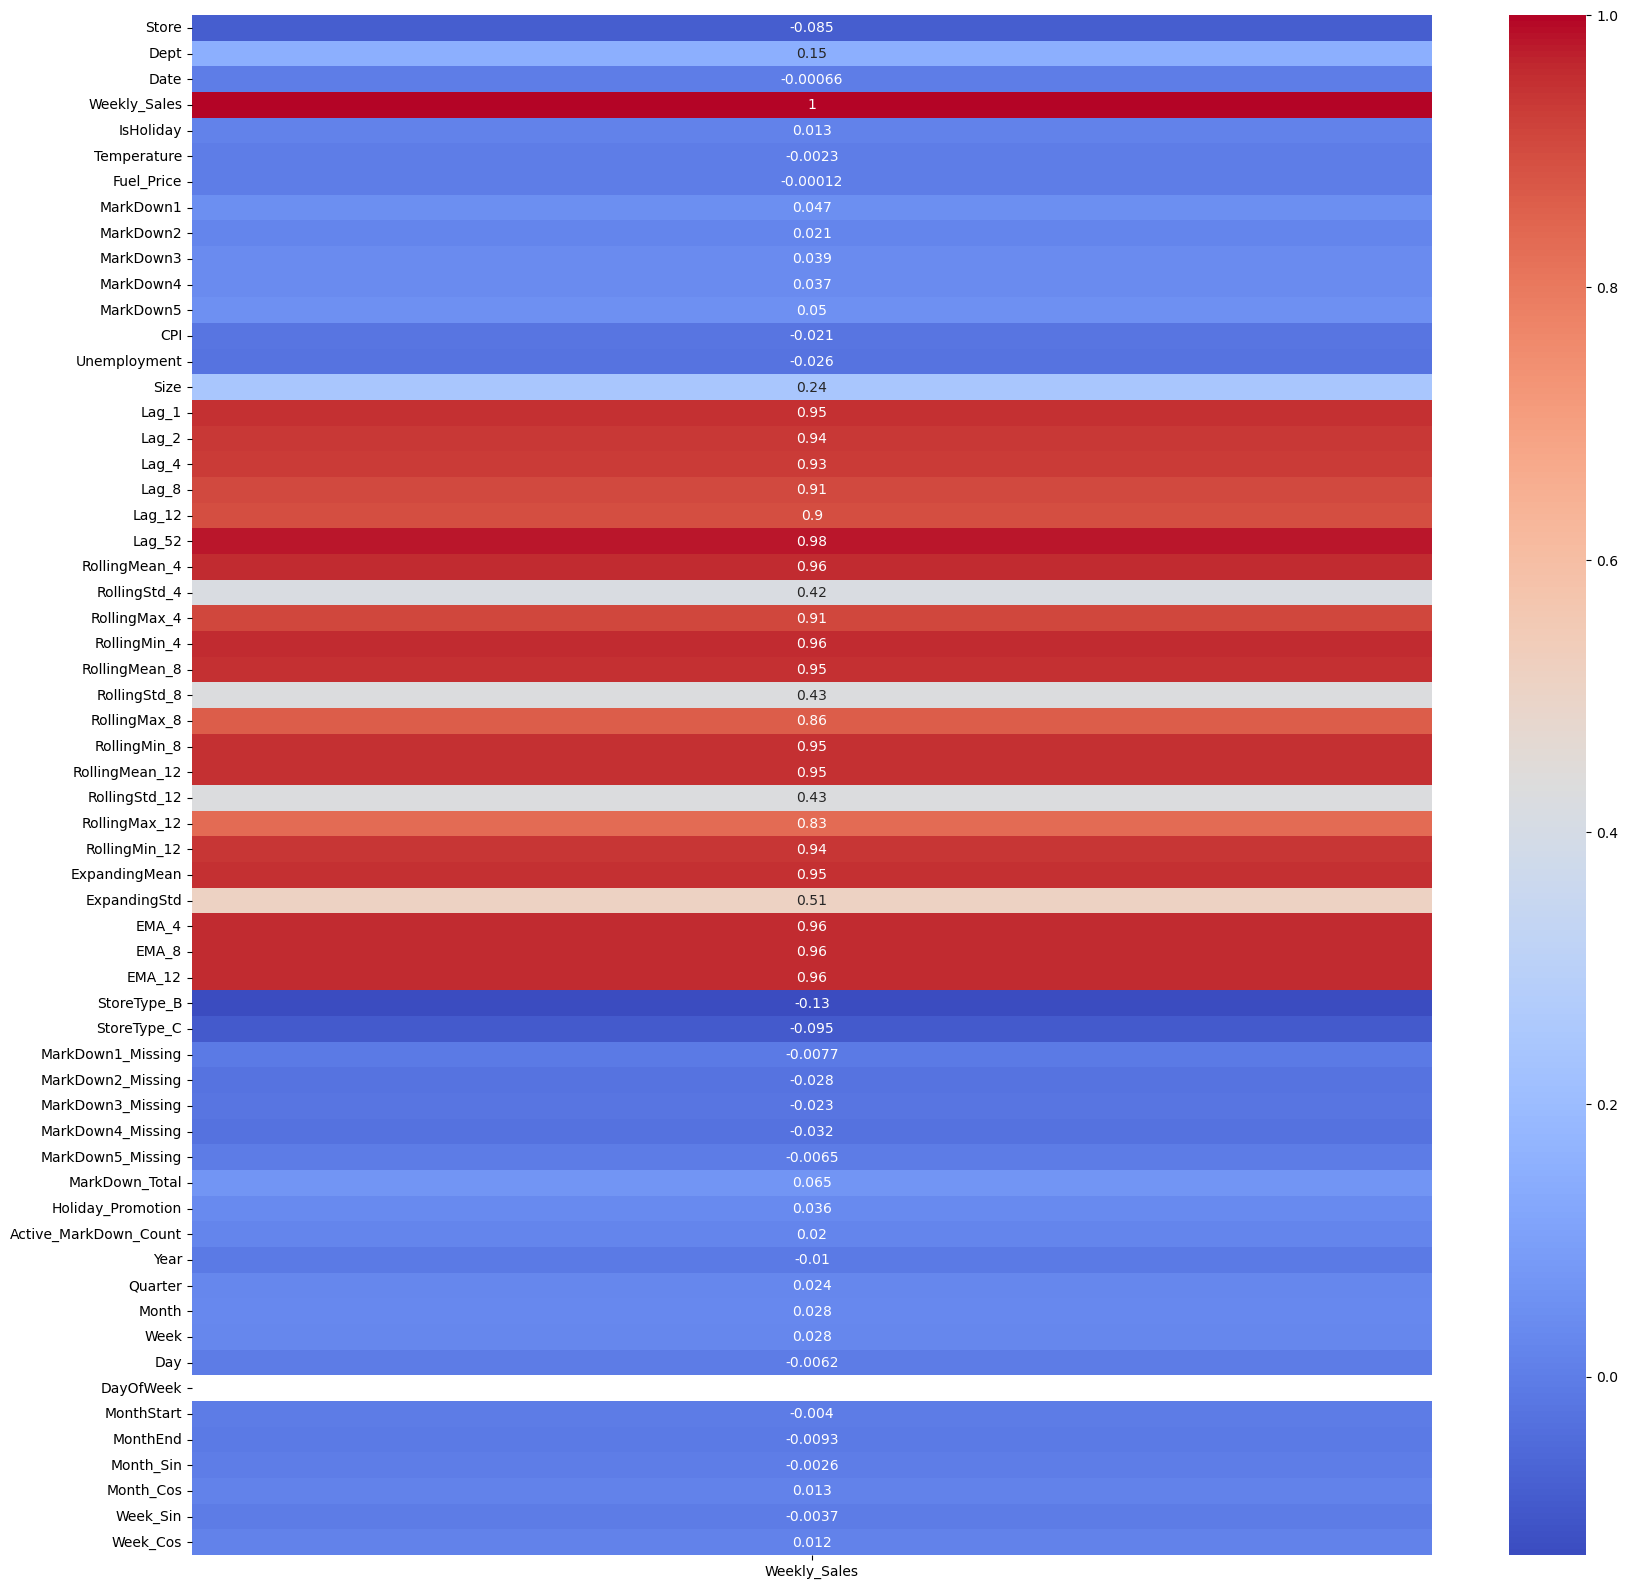

In [ ]:
import seaborn as sns
plt.figure(figsize=(20,20))
sns.heatmap(df.corr()[['Weekly_Sales']],annot=True, cmap='coolwarm')
plt.show()